# Simple Content-Based Recommender with TF-IDF

This notebook builds item embeddings from MovieLens movie metadata with TF-IDF, then recommends movies similar to what a user has already rated highly.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')
tags = pd.read_csv('tags.csv')

print(f'ratings: {ratings.shape[0]:,} rows')
print(f'movies: {movies.shape[0]:,} rows')
print(f'tags: {tags.shape[0]:,} rows')
movies.head()

ratings: 100,836 rows
movies: 9,742 rows
tags: 3,683 rows


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


## Prepare movie content

A content-based recommender needs a text description for each item. Here each movie description combines its title, genres, and user-applied tags.

In [2]:
movie_tags = (
    tags.assign(tag=tags['tag'].fillna('').astype(str).str.lower())
    .groupby('movieId')['tag']
    .apply(lambda values: ' '.join(values))
    .rename('tag_text')
)

movie_features = movies.merge(movie_tags, on='movieId', how='left')
movie_features['tag_text'] = movie_features['tag_text'].fillna('')
movie_features['genres_text'] = (
    movie_features['genres']
    .fillna('')
    .str.replace('|', ' ', regex=False)
    .str.replace('(no genres listed)', '', regex=False)
)
movie_features['content_text'] = (
    movie_features['title'].fillna('')
    + ' '
    + movie_features['genres_text']
    + ' '
    + movie_features['tag_text']
)

movie_to_idx = pd.Series(movie_features.index, index=movie_features['movieId']).to_dict()
idx_to_movie = pd.Series(movie_features['movieId'].values, index=movie_features.index).to_dict()

print(f'movies with content rows: {len(movie_features):,}')
movie_features[['movieId', 'title', 'genres', 'tag_text', 'content_text']].head()

movies with content rows: 9,742


,movieId,title,genres,tag_text,content_text
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,pixar pixar fun,Toy Story (1995) Adventure Animation Children ...
1,2,Jumanji (1995),Adventure|Children|Fantasy,fantasy magic board game robin williams game,Jumanji (1995) Adventure Children Fantasy fant...
2,3,Grumpier Old Men (1995),Comedy|Romance,moldy old,Grumpier Old Men (1995) Comedy Romance moldy old
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,,Waiting to Exhale (1995) Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,pregnancy remake,Father of the Bride Part II (1995) Comedy preg...


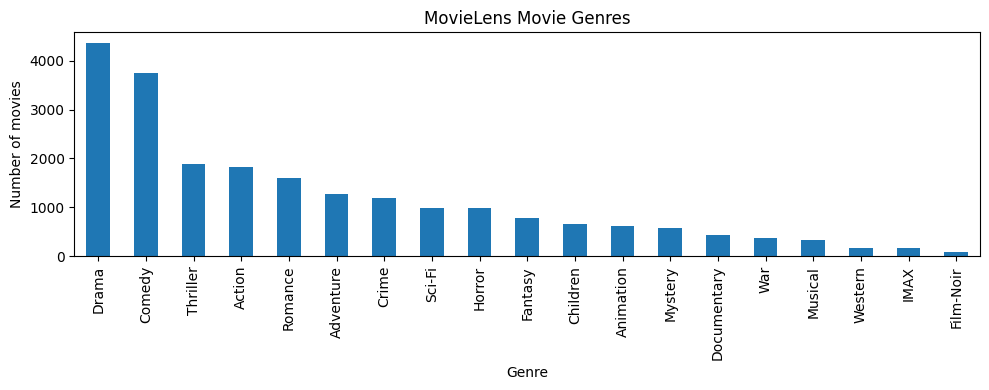

In [3]:
genre_counts = (
    movies['genres']
    .str.split('|')
    .explode()
    .loc[lambda values: values != '(no genres listed)']
    .value_counts()
)

plt.figure(figsize=(10, 4))
genre_counts.plot(kind='bar')
plt.title('MovieLens Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Number of movies')
plt.tight_layout()
plt.show()

## Create TF-IDF item embeddings

TF-IDF turns each movie's content text into a sparse vector. Cosine similarity between vectors gives a simple way to find content-similar movies.

In [4]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1, 2),
    min_df=1,
)

item_embeddings = vectorizer.fit_transform(movie_features['content_text'])

print(f'item embedding matrix: {item_embeddings.shape[0]:,} movies x {item_embeddings.shape[1]:,} terms')
print(f'non-zero TF-IDF values: {item_embeddings.nnz:,}')

feature_names = np.array(vectorizer.get_feature_names_out())

def top_tfidf_terms(movie_id, top_n=10):
    if movie_id not in movie_to_idx:
        raise ValueError(f'Unknown movie_id: {movie_id}')

    movie_idx = movie_to_idx[movie_id]
    row = item_embeddings[movie_idx]
    top_positions = np.argsort(row.toarray().ravel())[-top_n:][::-1]

    return pd.DataFrame({
        'term': feature_names[top_positions],
        'tfidf': row[:, top_positions].toarray().ravel(),
    })

toy_story_id = 1
print(movie_features.loc[movie_to_idx[toy_story_id], 'title'])
top_tfidf_terms(toy_story_id)

item embedding matrix: 9,742 movies x 35,251 terms
non-zero TF-IDF values: 109,979
Toy Story (1995)


,term,tfidf
0,pixar,0.519014
1,pixar fun,0.287237
2,pixar pixar,0.287237
3,fantasy pixar,0.287237
4,story 1995,0.266260
5,toy story,0.266260
6,toy,0.253989
7,fun,0.238530
8,1995 adventure,0.217553
9,story,0.170397


## Find similar movies

Before recommending for a user, it helps to check whether the item embeddings retrieve reasonable neighbors for a single movie.

In [5]:
def similar_movies(movie_id, top_n=10):
    if movie_id not in movie_to_idx:
        raise ValueError(f'Unknown movie_id: {movie_id}')

    movie_idx = movie_to_idx[movie_id]
    scores = cosine_similarity(item_embeddings[movie_idx], item_embeddings).ravel()
    scores[movie_idx] = -np.inf

    top_positions = np.argsort(scores)[-top_n:][::-1]
    top_movie_ids = [idx_to_movie[idx] for idx in top_positions]

    return (
        pd.DataFrame({'movieId': top_movie_ids, 'similarity': scores[top_positions]})
        .merge(movies, on='movieId', how='left')
        [['title', 'genres', 'similarity']]
    )

similar_movies(movie_id=1, top_n=10)

,title,genres,similarity
0,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.427203
1,Toy Story 3 (2010),Adventure|Animation|Children|Comedy|Fantasy|IMAX,0.408300
2,"Bug's Life, A (1998)",Adventure|Animation|Children|Comedy,0.300218
3,Balto (1995),Adventure|Animation|Children,0.251743
4,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,0.222149
5,"Monsters, Inc. (2001)",Adventure|Animation|Children|Comedy|Fantasy,0.216228
6,Shrek the Third (2007),Adventure|Animation|Children|Comedy|Fantasy,0.212581
7,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,0.211453
8,Antz (1998),Adventure|Animation|Children|Comedy|Fantasy,0.208161
9,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,0.206514


## Recommend movies for one user

For a selected user, average the TF-IDF vectors for movies they rated highly, then score unseen movies by cosine similarity to that user profile.

In [6]:
movie_rating_counts = ratings.groupby('movieId').size()


def show_user_likes(user_id, top_n=10):
    user_ratings = ratings.loc[ratings['userId'] == user_id, ['movieId', 'rating']]
    if user_ratings.empty:
        raise ValueError(f'Unknown user_id: {user_id}')

    return (
        user_ratings
        .merge(movies, on='movieId', how='left')
        .sort_values(['rating', 'title'], ascending=[False, True])
        .head(top_n)
        [['title', 'genres', 'rating']]
    )


def build_user_profile(user_id, min_rating=4.0):
    user_ratings = ratings.loc[ratings['userId'] == user_id, ['movieId', 'rating']].copy()
    if user_ratings.empty:
        raise ValueError(f'Unknown user_id: {user_id}')

    liked = user_ratings[user_ratings['rating'] >= min_rating].copy()
    if liked.empty:
        liked = user_ratings.copy()

    liked['movie_idx'] = liked['movieId'].map(movie_to_idx)
    liked = liked.dropna(subset=['movie_idx'])
    liked['movie_idx'] = liked['movie_idx'].astype(int)

    weights = liked['rating'].to_numpy(dtype=np.float32)
    weights = weights / weights.sum()

    weighted_items = item_embeddings[liked['movie_idx'].to_numpy()].multiply(weights[:, None])
    return np.asarray(weighted_items.sum(axis=0))


def recommend_for_user(user_id, top_n=10, min_rating=4.0, min_ratings=5):
    profile = build_user_profile(user_id=user_id, min_rating=min_rating)

    rated_movie_ids = set(ratings.loc[ratings['userId'] == user_id, 'movieId'])
    eligible_movie_ids = set(movie_rating_counts[movie_rating_counts >= min_ratings].index)

    candidate_movie_idx = np.array(
        [
            idx
            for idx, movie_id in idx_to_movie.items()
            if movie_id not in rated_movie_ids and movie_id in eligible_movie_ids
        ],
        dtype=np.int64,
    )
    if len(candidate_movie_idx) == 0:
        return pd.DataFrame(columns=['title', 'genres', 'similarity'])

    scores = cosine_similarity(profile, item_embeddings[candidate_movie_idx]).ravel()
    top_positions = np.argsort(scores)[-top_n:][::-1]
    top_movie_ids = [idx_to_movie[idx] for idx in candidate_movie_idx[top_positions]]

    return (
        pd.DataFrame({'movieId': top_movie_ids, 'similarity': scores[top_positions]})
        .merge(movies, on='movieId', how='left')
        [['title', 'genres', 'similarity']]
    )


user_id = 1

user_likes = show_user_likes(user_id=user_id, top_n=10)
recommendations = recommend_for_user(user_id=user_id, top_n=10)

print(f'User {user_id} highest-rated movies:')
display(user_likes)

print(f'Recommendations for user {user_id}:')
display(recommendations)

User 1 highest-rated movies:


,title,genres,rating
46,"Adventures of Robin Hood, The (1938)",Action|Adventure|Romance,5.0
56,Alice in Wonderland (1951),Adventure|Animation|Children|Fantasy|Musical,5.0
114,All Quiet on the Western Front (1930),Action|Drama|War,5.0
184,American Beauty (1999),Drama|Romance,5.0
147,American History X (1998),Crime|Drama,5.0
138,"American Tail, An (1986)",Adventure|Animation|Children|Comedy,5.0
98,Austin Powers: International Man of Mystery (1...,Action|Adventure|Comedy,5.0
85,Back to the Future (1985),Adventure|Comedy|Sci-Fi,5.0
120,Bambi (1942),Animation|Children|Drama,5.0
64,Basic Instinct (1992),Crime|Mystery|Thriller,5.0


Recommendations for user 1:


,title,genres,similarity
0,Titan A.E. (2000),Action|Adventure|Animation|Children|Sci-Fi,0.319138
1,Home (2015),Adventure|Animation|Children|Comedy|Fantasy|Sc...,0.318102
2,"Pagemaster, The (1994)",Action|Adventure|Animation|Children|Fantasy,0.312049
3,Chicken Little (2005),Action|Adventure|Animation|Children|Comedy|Sci-Fi,0.304942
4,Robots (2005),Adventure|Animation|Children|Comedy|Fantasy|Sc...,0.297303
5,Escape from L.A. (1996),Action|Adventure|Sci-Fi|Thriller,0.289231
6,Children of Men (2006),Action|Adventure|Drama|Sci-Fi|Thriller,0.286345
7,Pokémon: The First Movie (1998),Adventure|Animation|Children|Fantasy|Sci-Fi,0.285933
8,Bolt (2008),Action|Adventure|Animation|Children|Comedy,0.283608
9,Spawn (1997),Action|Adventure|Sci-Fi|Thriller,0.281523
